In [1]:
import os
import zipfile
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
SEED = 42


In [3]:
ZIP_PATH = "/content/skinconditionsdatasets.zip"
BASE_DIR = "/content/skin_data"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(BASE_DIR)

print("Extracted:", os.listdir(BASE_DIR))


Extracted: ['Skin_Conditions']


In [4]:
DATASET_DIR = os.path.join(BASE_DIR, "Skin_Conditions")

print("Classes:", os.listdir(DATASET_DIR))


Classes: ['Acne', 'Eczema', 'Carcinoma', 'Keratosis', 'Rosacea', 'Milia']


In [5]:
CLASS_NAMES = [
    "Acne",
    "Carcinoma",
    "Eczema",
    "Keratosis",
    "Milia",
    "Rosacea"
]

NUM_CLASSES = len(CLASS_NAMES)


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,      # 🔒 LOCKED
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,      # 🔒 LOCKED
    subset="validation",
    shuffle=False
)


Found 1920 images belonging to 6 classes.
Found 474 images belonging to 6 classes.


In [7]:
class_labels = {name: idx for idx, name in enumerate(CLASS_NAMES)}

with open("class_labels.json", "w") as f:
    json.dump(class_labels, f, indent=2)

print(class_labels)


{'Acne': 0, 'Carcinoma': 1, 'Eczema': 2, 'Keratosis': 3, 'Milia': 4, 'Rosacea': 5}


In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=outputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint(
        "skin_model.h5",
        save_best_only=True,
        monitor="val_accuracy"
    )
]


In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.2900 - loss: 1.8096

60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 431ms/step - accuracy: 0.2913 - loss: 1.8062 - val_accuracy: 0.6118 - val_loss: 1.1930
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5786 - loss: 1.1935

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.5790 - loss: 1.1927 - val_accuracy: 0.6878 - val_loss: 0.9323
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6761 - loss: 0.9480

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.6764 - loss: 0.9472 - val_accuracy: 0.7384 - val_loss: 0.7962
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7285 - loss: 0.8179

...

60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.9045 - loss: 0.3334 - val_accuracy: 0.8586 - val_loss: 0.4317
Epoch 18/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9118 - loss: 0.3031 - val_accuracy: 0.8523 - val_loss: 0.4250
Epoch 19/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.9113 - loss: 0.2916 - val_accuracy: 0.8586 - val_loss: 0.4126
Epoch 20/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9178 - loss: 0.2695

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.9178 - loss: 0.2696 - val_accuracy: 0.8608 - val_loss: 0.4170
Epoch 21/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9213 - loss: 0.2598 - val_accuracy: 0.8502 - val_loss: 0.4117
Epoch 22/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9285 - loss: 0.2554

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9285 - loss: 0.2554 - val_accuracy: 0.8650 - val_loss: 0.3966
Epoch 23/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9365 - loss: 0.2326

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9364 - loss: 0.2327 - val_accuracy: 0.8713 - val_loss: 0.3896
Epoch 24/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9419 - loss: 0.2253 - val_accuracy: 0.8692 - val_loss: 0.3842
Epoch 25/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9330 - loss: 0.2280

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.9331 - loss: 0.2278 - val_accuracy: 0.8797 - val_loss: 0.3767


In [12]:
import json

# Save training history
with open("training_history.json", "w") as f:
    json.dump(history.history, f)

print("Training history saved as training_history.json")


Training history saved as training_history.json


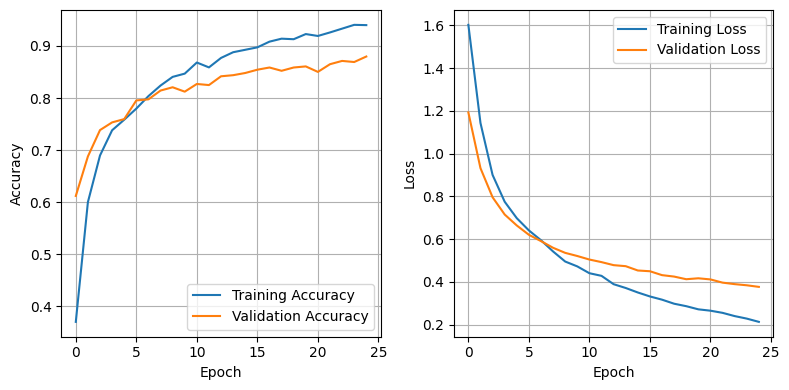

In [13]:
import matplotlib.pyplot as plt

# history is returned by model.fit(...)
# example: history = model.fit(...)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 437ms/step


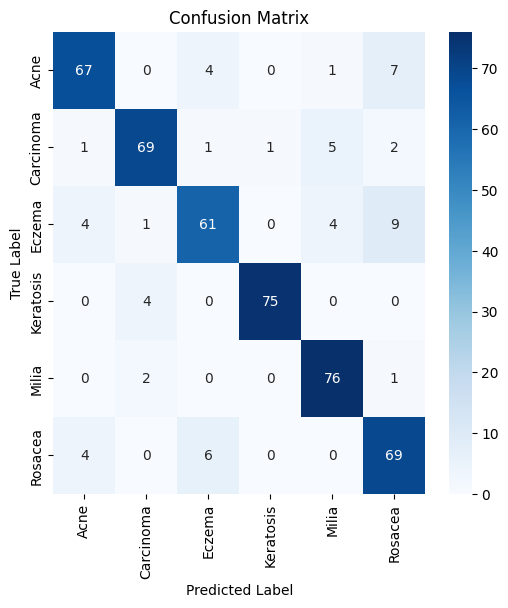

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict on validation data
val_gen.reset()
pred_probs = model.predict(val_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


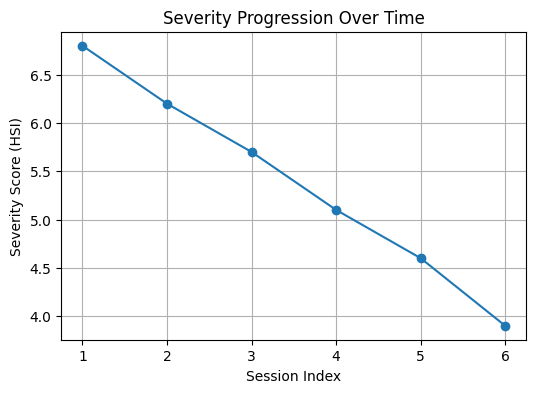

In [15]:
# Example severity scores across sessions (illustrative)
sessions = [1, 2, 3, 4, 5, 6]
severity_scores = [6.8, 6.2, 5.7, 5.1, 4.6, 3.9]

plt.figure(figsize=(6, 4))
plt.plot(sessions, severity_scores, marker='o')
plt.xlabel('Session Index')
plt.ylabel('Severity Score (HSI)')
plt.title('Severity Progression Over Time')
plt.grid(True)
plt.show()


In [16]:
print("Model output shape:", model.output_shape)
print("Class indices:", train_gen.class_indices)


Model output shape: (None, 6)
Class indices: {'Acne': 0, 'Carcinoma': 1, 'Eczema': 2, 'Keratosis': 3, 'Milia': 4, 'Rosacea': 5}


In [17]:
import json

with open("training_history.json", "w") as f:
    json.dump(history.history, f)


In [18]:
from tensorflow.keras.utils import load_img, img_to_array

test_path = train_gen.filepaths[0]

img = load_img(test_path, target_size=IMG_SIZE)
img = img_to_array(img) / 255.0
img = np.expand_dims(img, axis=0)

pred = model.predict(img)
idx = np.argmax(pred[0])

print("Predicted:", CLASS_NAMES[idx])
print("Confidence:", pred[0][idx])


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted: Acne
Confidence: 0.56389123


In [ ]:
import tensorflow as tf

# Load old model
model = tf.keras.models.load_model("skin_model.h5", compile=False)

print("✅ Model loaded")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

# Save in NEW format (IMPORTANT)
model.save("skin_model.keras")

print("✅ Saved as skin_model.keras")


✅ Model loaded
Input shape: (None, 224, 224, 3)
Output shape: (None, 6)
✅ Saved as skin_model.keras


In [19]:
import tensorflow as tf

print("TF version:", tf.__version__)

# Force TF-Keras loading
model = tf.keras.models.load_model(
    "skin_model.h5",
    compile=False,
    custom_objects={}
)

print("Loaded with tf.keras")

# Rebuild model graph (important)
model = tf.keras.Model(
    inputs=model.input,
    outputs=model.output,
    name="skin_condition_model"
)

# Save in TF-native format
model.save("skin_model_tf.keras", save_format="keras")

print("✅ Saved as skin_model_tf.keras")


TF version: 2.19.0


Loaded with tf.keras
✅ Saved as skin_model_tf.keras
